# 12 Dual-electrode cell (US12308414B2)

Charge: iron–OER–source. Discharge: iron–ORR–load (EP [0049]). Independent $L_\mathrm{c}$ vs $L_\mathrm{d}$ (US $100\,\mathrm{h}$ / $300\,\mathrm{h}$).

## Governing equations

See the requirement UID and patent claims cited in the title cell. Default electrolyte $6\,\mathrm{M}$ KOH at $303\,\mathrm{K}$ and $1\,\mathrm{atm}$. Currents in $\mathrm{A}$, voltages in $\mathrm{V}$, power in $\mathrm{W}$. Chemistry remains $\mathrm{...}$ (not mhchem).


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

here = Path.cwd()
for cand in (here, here.parent):
    if (cand / "src" / "ironair").is_dir() and (cand / "plant_sim").is_dir():
        sys.path.insert(0, str(cand))
        sys.path.insert(0, str(cand / "src"))
        break

from plant_sim.bootstrap import setup_path

setup_path()
from plant_sim.params import CAPACITY_FE_OH2_MAH_G, CAPACITY_MAGNETITE_MAH_G, default_params

In [2]:
from IPython import get_ipython

_ipy = get_ipython()
if _ipy is not None:
    _ipy.run_line_magic("matplotlib", "inline")

sns.set(
    rc={
        "axes.labelsize": 12,
        "axes.titlesize": 18,
        "figure.figsize": (11, 8.5),
        "figure.dpi": 300,
        "figure.facecolor": "w",
        "figure.edgecolor": "k",
    }
)
P = default_params()
print("KOH default", P.c_KOH_mol_m3 / 1000, "M; T_ep", P.T_ep_sim_K, "K")
print("Faraday 960/320 checks", round(CAPACITY_FE_OH2_MAH_G, 2), round(CAPACITY_MAGNETITE_MAH_G, 2))

KOH default 6.0 M; T_ep 303.15 K
Faraday 960/320 checks 959.85 319.95


## Simulation setup

Integrate the model once. Plot sections below each document what is shown, why it matters for patent/requirement verification, and the equations that govern that view.


In [3]:
from plant_sim.substructures.dual_electrode_cell import DualElectrodeCell

cell = DualElectrodeCell(P)
dch = cell.simulate((0, 600), u={"mode": -1.0, "I_cell_A": 15 * P.I_discharge_100h_A})
chg = cell.simulate((0, 600), u={"mode": 1.0, "I_cell_A": 15 * P.I_discharge_100h_A})

## Dual-electrode discharge through ORR

### What this plot illustrates

During discharge the plant routes current through the ORR electrode while the OER path is idle/isolated (EP [0049]; US Claim 16).

### Governing equations

Discharge path: iron oxidation + ORR. $I_\mathrm{cell}=I_\mathrm{Fe}=I_\mathrm{ORR}$, $I_\mathrm{OER}\approx 0$.


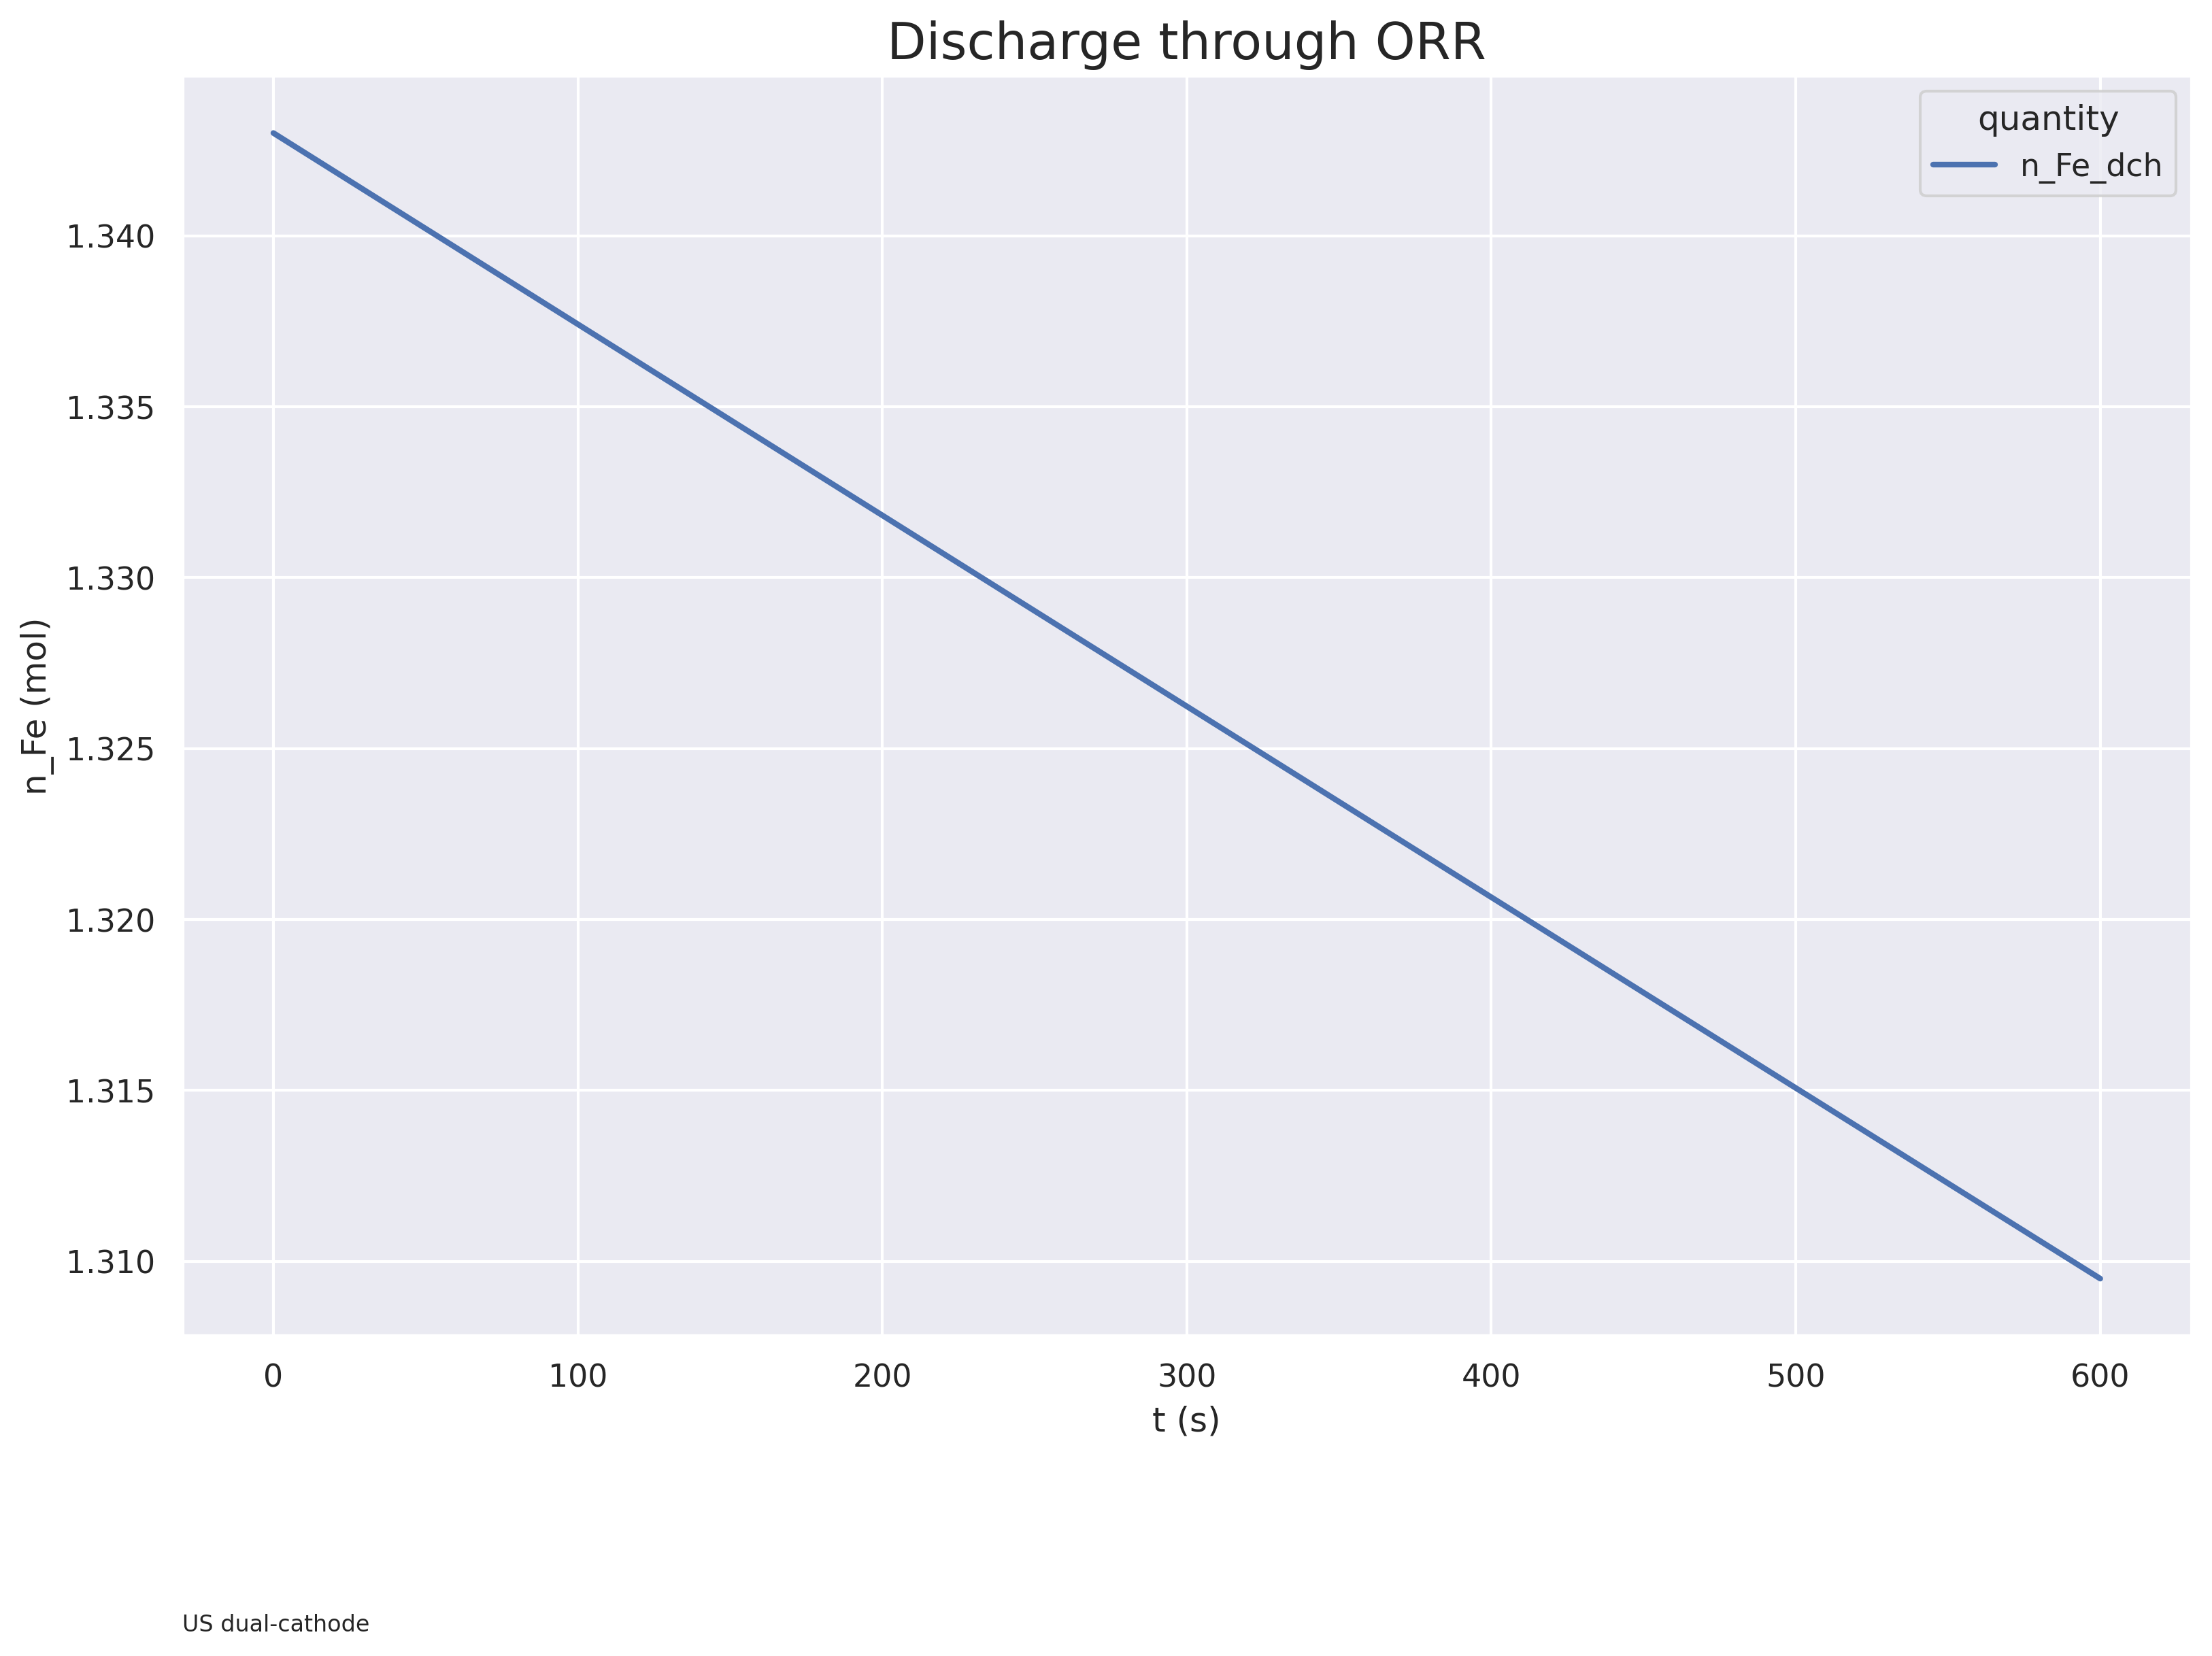

In [4]:
plot_frame = pd.DataFrame(
    {
        "t": (dch["t"]),
        "n_Fe_dch": (dch["y"][0]),
    }
)
plot_long = plot_frame.melt(id_vars="t", var_name="quantity", value_name="value")
fig, ax = plt.subplots()
sns.lineplot(data=plot_long, x="t", y="value", hue="quantity", ax=ax, linewidth=2.0)
ax.set_xlabel("t (s)")
ax.set_ylabel("n_Fe (mol)")
ax.set_title("Discharge through ORR")
ax.text(0.0, -0.22, "US dual-cathode", transform=ax.transAxes, fontsize=8, va="top")
fig.tight_layout()
fig.subplots_adjust(bottom=0.22)

## Dual-electrode charge through OER with HER

### What this plot illustrates

During charge, current returns iron via OER while parasitic HER reduces CE; ORR is isolated from gas evolution.

### Governing equations

Charge path: iron reduction + OER. $I_\mathrm{cell}=I_\mathrm{Fe}+I_\mathrm{HER}=I_\mathrm{OER}$.


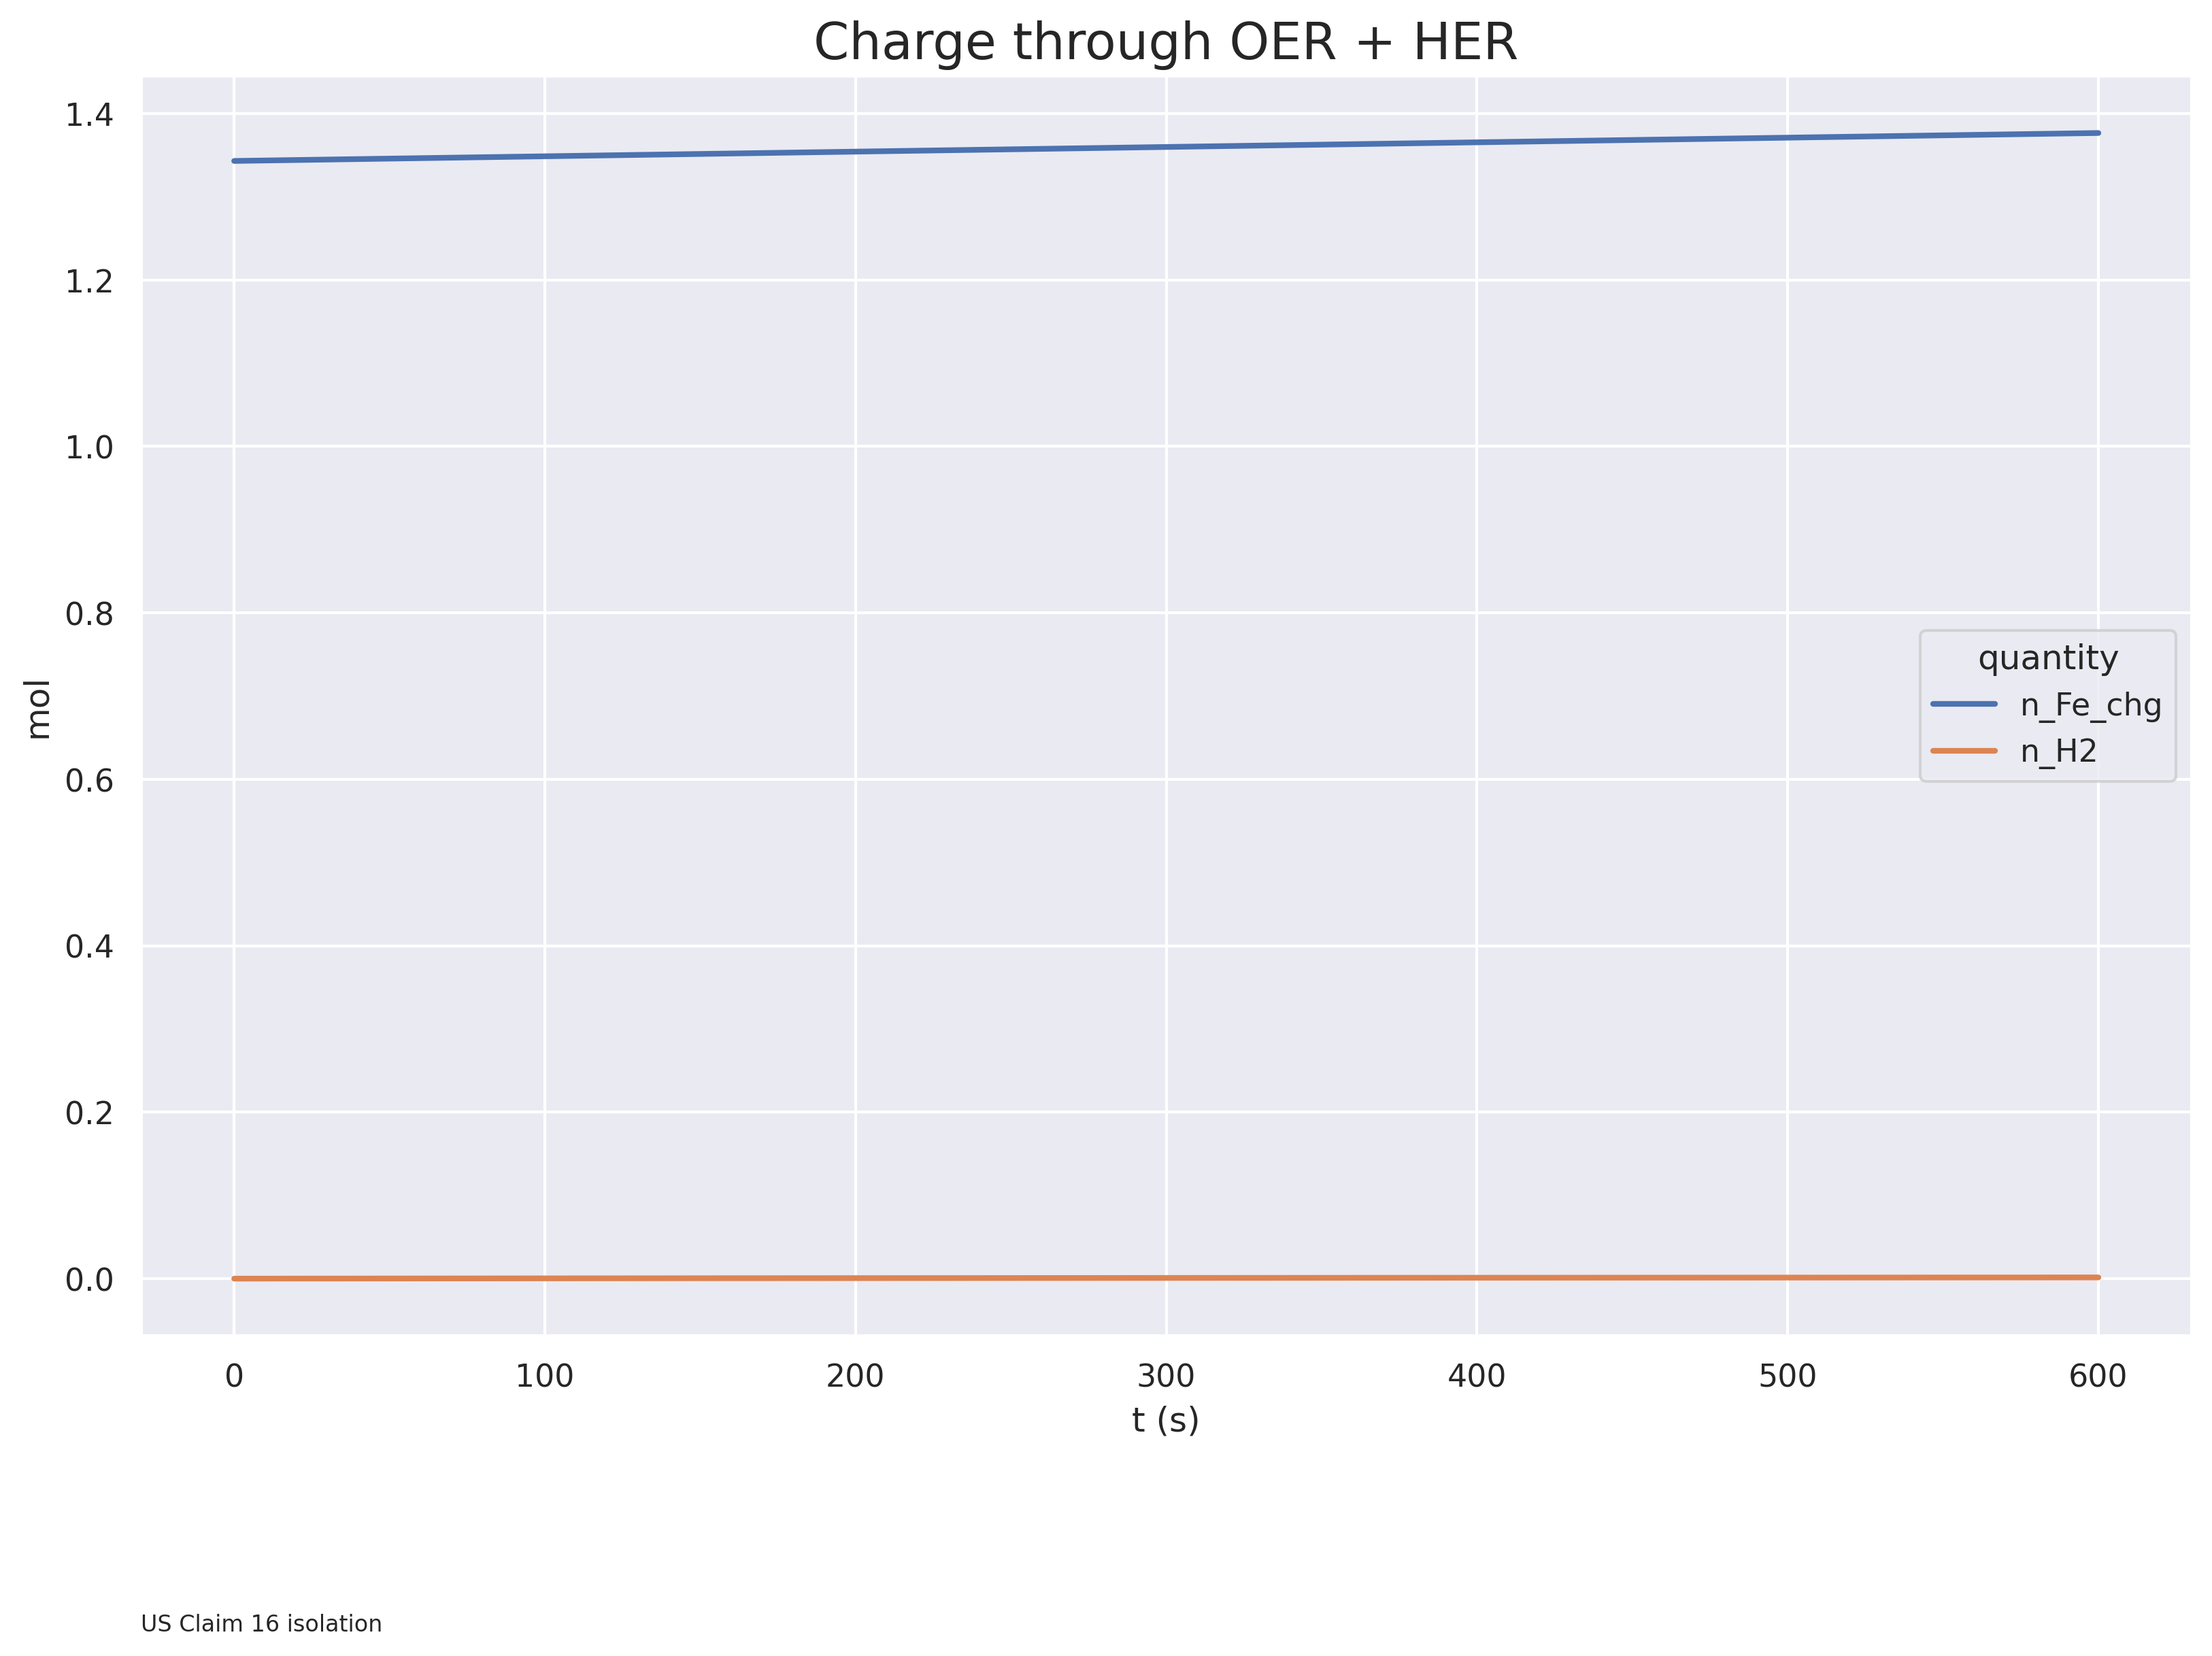

In [5]:
plot_frame = pd.DataFrame(
    {
        "t": (chg["t"]),
        "n_Fe_chg": (chg["y"][0]),
        "n_H2": (chg["y"][8]),
    }
)
plot_long = plot_frame.melt(id_vars="t", var_name="quantity", value_name="value")
fig, ax = plt.subplots()
sns.lineplot(data=plot_long, x="t", y="value", hue="quantity", ax=ax, linewidth=2.0)
ax.set_xlabel("t (s)")
ax.set_ylabel("mol")
ax.set_title("Charge through OER + HER")
ax.text(0.0, -0.22, "US Claim 16 isolation", transform=ax.transAxes, fontsize=8, va="top")
fig.tight_layout()
fig.subplots_adjust(bottom=0.22)